# Passo 1 - coleta de dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
df= pd.read_csv('base_iris.csv');

# print(df.describe())
# print(df)
# print(f'linhas:{df.shape[0]} colunas: {df.shape[1]}')


# Limpeza Estrutural

linhas:145


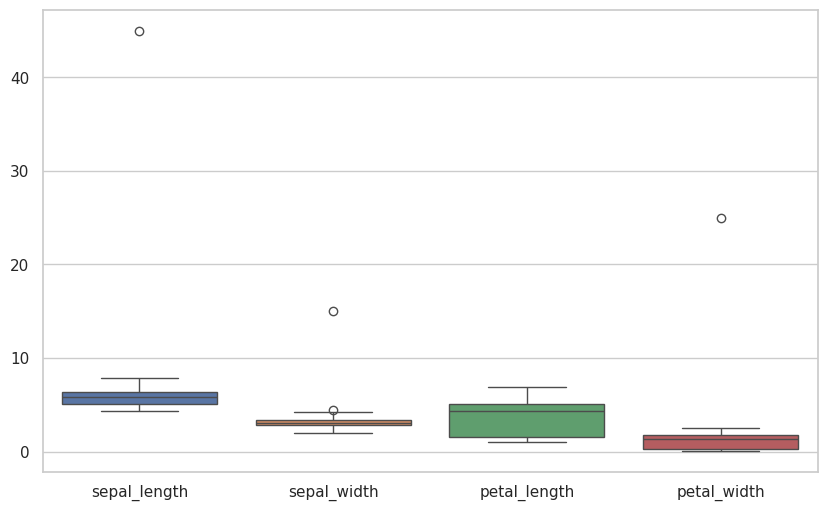

In [ ]:
from numpy import indices
# removendo coluna Unnamed
if 'Unnamed: 0' in df.columns:
  df = df.drop(columns=['Unnamed: 0'])
# remover targerts nulos
df = df.dropna(subset=["target"])
# remover duplicadtas
df = df.drop_duplicates()
# remover valores negativos
colunas_analogicas=['petal_length','petal_width','sepal_length','sepal_width']
df=df.drop(df[(df[colunas_analogicas]<=0).any(axis=1)].index)



print(f'linhas:{df.shape[0]}')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.show()

# 3. Divisão

In [ ]:
x = df.drop(columns='target')
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

print(f'treino: {x_train.shape}')
print(f'teste: {x_test.shape}')

treino: (101, 4)
teste: (44, 4)


# passo 4: Pré Processamento

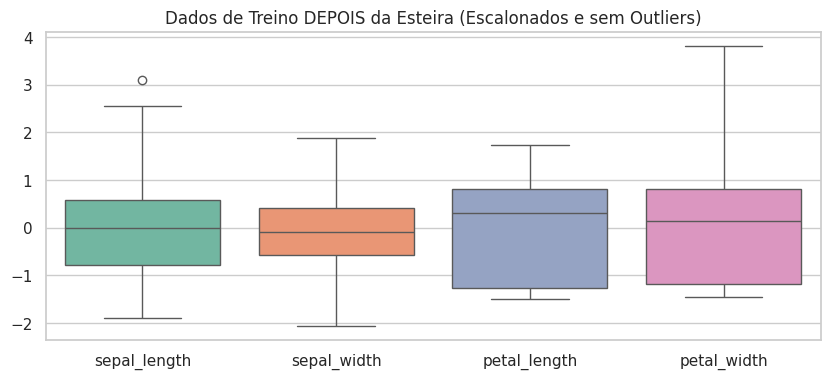

treino: (101, 4)
teste: (44, 4)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

class TratadorOutliersIQR(BaseEstimator, TransformerMixin):
    def __init__(self, fator=1.5):
        self.fator = fator
        self.limites = {}

    def fit(self, X, y=None):
        # A máquina "aprende" os limites APENAS olhando para os dados que entram aqui (Treino)
        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.limites[col] = {
                'inferior': Q1 - self.fator * IQR,
                'superior': Q3 + self.fator * IQR
            }
        return self

    def transform(self, X):
        # A máquina aplica os limites aprendidos nos dados (Treino ou Teste)
        X_tratado = X.copy()
        for col, limites in self.limites.items():
            X_tratado[col] = X_tratado[col].clip(lower=limites['inferior'], upper=limites['superior'])
        return X_tratado


esteira_processamento = Pipeline(steps=[
    ('outliers', TratadorOutliersIQR()),         # 1º: Corta os outliers usando regras do treino
    ('imputer', SimpleImputer(strategy='mean')), # 2º: Preenche nulos com a média limpa
    ('scaler', StandardScaler())                 # 3º: Coloca na mesma escala
])
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns
x_train_tratado = esteira_processamento.fit_transform(x_train)
x_test_tratado = esteira_processamento.transform(x_test)
codificador_alvo = LabelEncoder()
y_train_codificado = codificador_alvo.fit_transform(y_train)
y_test_codificado = codificador_alvo.fit_transform(y_test)
# (Opcional) Visão dos dados de treino após passar pela esteira
X_train_vis = pd.DataFrame(x_train_tratado, columns=cols_numericas)
plt.figure(figsize=(10, 4))
sns.boxplot(data=X_train_vis, palette="Set2")
plt.title("Dados de Treino DEPOIS da Esteira (Escalonados e sem Outliers)")
plt.show()

print(f'treino: {x_train_tratado.shape}')
print(f'teste: {x_test_tratado.shape}')

## escolha do modelo

In [ ]:
# from sklearn.tree import DecisionTreeClassifier
# ## ecolha e cofr do modelo
# modelo_arvore = DecisionTreeClassifier(random_state=42, max_depth=3)
# ##treino do modelo
# modelo_arvore.fit(x_train_tratado, y_train_codificado)

### Pré-poda

In [ ]:
from sklearn.tree import DecisionTreeClassifier
## ecolha e cofr do modelo e aplikando pré-pode
modelo_arvore = DecisionTreeClassifier(random_state=42, max_depth=3, min_samples_split=10, min_samples_leaf=5)
##treino do modelo
modelo_arvore.fit(x_train_tratado, y_train_codificado)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=10)

###   PÓS-PODA

In [ ]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# ## ecolha e cofr do modelo
# modelo_arvore_inicial = DecisionTreeClassifier(random_state=42)
# path=modelo_arvore_inicial.cost_complexity_pruning_path(x_train_tratado, y_train_codificado)
# ccp_alphas = path.ccp_alphas[:-1]



In [ ]:

# melhor_modelo_arvore =None
# melhor_acuracia = 0
# #tratamento pós-poda e treino
# for ccp_alpha in ccp_alphas:
#     modelo_arvore_temp = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
#     modelo_arvore_temp.fit(x_train_tratado, y_train_codificado)
#     acuracia_teste = modelo_arvore_temp.score(x_test_tratado, y_test_codificado)

#     if acuracia_teste > melhor_acuracia:
#         melhor_acuracia = acuracia_teste
#         melhor_modelo_arvore = modelo_arvore_temp

# # definindo modelo
# modelo_arvore = melhor_modelo_arvore


## avaliação e validação

Acurácia: 0.9772727272727273
Acurácia Treino: 0.9405940594059405
Matriz de Confusão:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 14]]


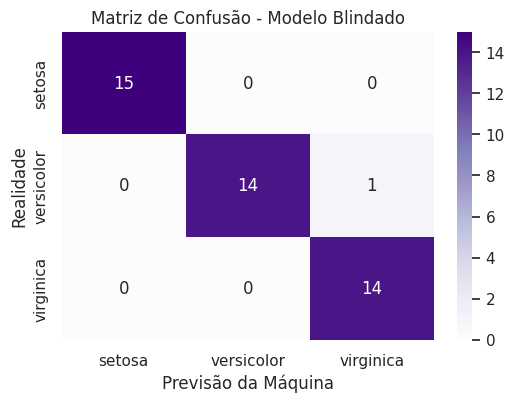

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Avaliação
predict_train = modelo_arvore.predict(x_train_tratado)
predict_test = modelo_arvore.predict(x_test_tratado)
#Validação
acuracia = accuracy_score(y_test_codificado, predict_test)
acuracia_treino = accuracy_score(y_train_codificado, predict_train)
print(f'Acurácia: {acuracia}')
print(f'Acurácia Treino: {acuracia_treino}')
#MATRIZ DE CONFUSÃO
matriz_confusao = confusion_matrix(y_test_codificado, predict_test)
print("Matriz de Confusão:")
print(matriz_confusao)
#plot dos resultados
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Purples',
            xticklabels=codificador_alvo.classes_,
            yticklabels=codificador_alvo.classes_)
plt.title('Matriz de Confusão - Modelo Blindado')
plt.xlabel('Previsão da Máquina')
plt.ylabel('Realidade')
plt.show()

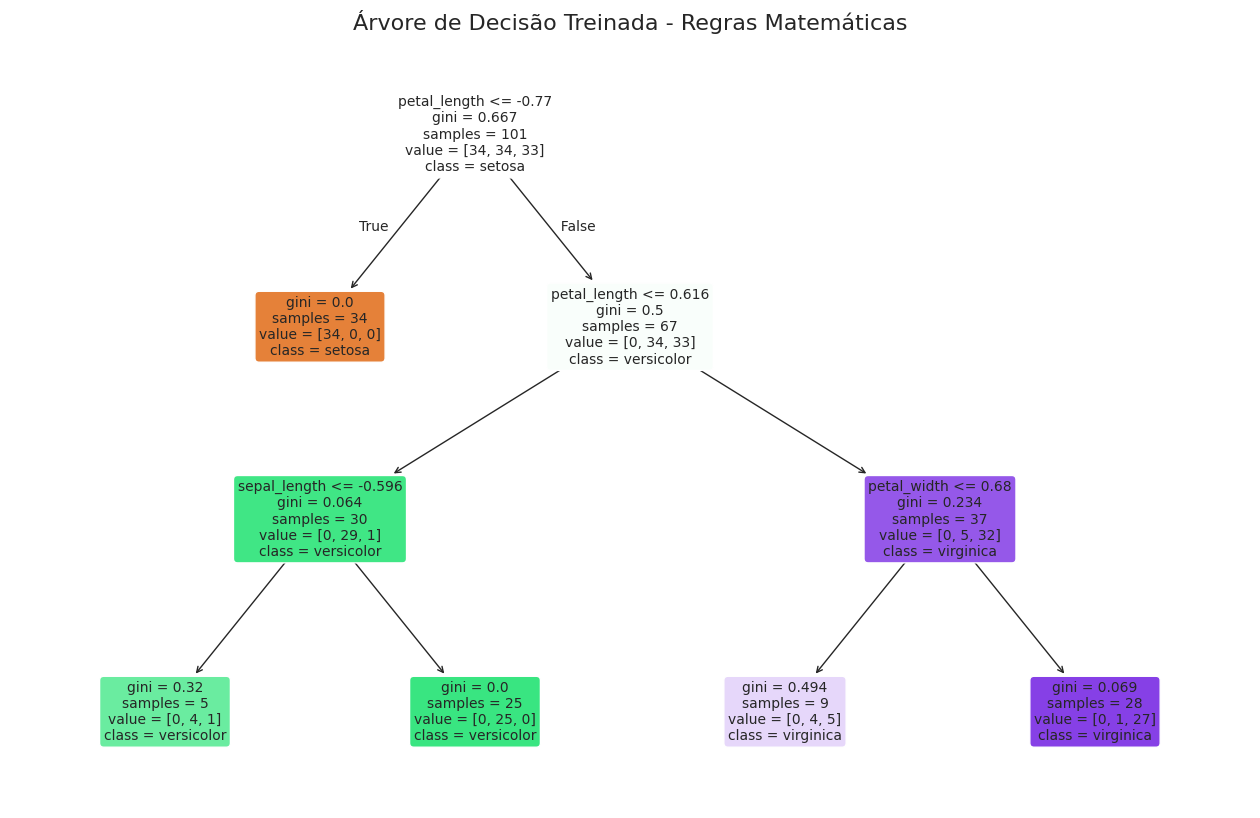

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Criar uma figura grande o suficiente para vermos os detalhes
plt.figure(figsize=(16, 10))

# Extrair os nomes das colunas (as nossas variáveis)
nomes_das_features = x.columns.tolist()

# Extrair os nomes das espécies (target) para o gráfico não mostrar apenas 0, 1 e 2
nomes_das_classes = codificador_alvo.classes_.tolist()

# Desenhar a árvore
plot_tree(modelo_arvore,
          feature_names=nomes_das_features,  # Mostra o nome da coluna usada na regra
          class_names=nomes_das_classes,     # Mostra o nome da espécie prevista
          filled=True,                       # Pinta as caixas com cores
          rounded=True,                      # Deixa os cantos das caixas arredondados
          fontsize=10)                       # Tamanho da letra

plt.title('Árvore de Decisão Treinada - Regras Matemáticas', fontsize=16)
plt.show()

#Usando random forest

In [ ]:
"""## 1. Coleta de Dados (A Extração da Matéria-Prima)"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")

# 1. Coleta de Dados
df = pd.read_csv('base_iris.csv')
print(f"Dados carregados! Formato inicial: {df.shape[0]} linhas e {df.shape[1]} colunas.")

"""## 2. Limpeza Estrutural, Exploração Visual e Tratamento de Outliers"""

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df = df.dropna(subset=['target'])
df = df.drop_duplicates()

print(f"Dados após limpeza estrutural: {df.shape[0]} linhas.")

"""## 3. Divisão dos Dados (O Isolamento) e Gráfico de Divisão"""

from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Cofre fechado! Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras.")
"""## 4. Pré-processamento (A Linha de Montagem Matemática)"""

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

class TratadorOutliersIQR(BaseEstimator, TransformerMixin):
    def __init__(self, fator=1.5):
        self.fator = fator
        self.limites = {}

    def fit(self, X, y=None):
        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.limites[col] = {
                'inferior': Q1 - self.fator * IQR,
                'superior': Q3 + self.fator * IQR
            }
        return self

    def transform(self, X):
        X_tratado = X.copy()
        for col, limites in self.limites.items():
            X_tratado[col] = X_tratado[col].clip(lower=limites['inferior'], upper=limites['superior'])
        return X_tratado

esteira_processamento = Pipeline(steps=[
    ('outliers', TratadorOutliersIQR()),
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_train_processado = esteira_processamento.fit_transform(X_train)
codificador_alvo = LabelEncoder()
y_train_codificado = codificador_alvo.fit_transform(y_train)


Dados carregados! Formato inicial: 150 linhas e 6 colunas.
Dados após limpeza estrutural: 146 linhas.
Cofre fechado! Treino: 102 amostras | Teste: 44 amostras.


In [ ]:
# Construindo a minha floresta
modelo_floresta = RandomForestClassifier(random_state=42, n_estimators=100)
# treino
modelo_floresta.fit(X_train_processado, y_train_codificado)

RandomForestClassifier(random_state=42)


🏆 Exatidão (Acurácia) Realista da Floresta: 95.45%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        14

    accuracy                           0.95        44
   macro avg       0.95      0.95      0.95        44
weighted avg       0.95      0.95      0.95        44



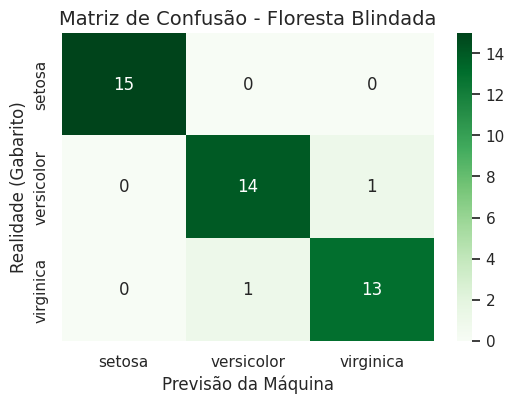

In [ ]:
"""## 6. Avaliação, Validação e Matriz de Confusão"""

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_test_processado = esteira_processamento.transform(X_test)
y_test_codificado = codificador_alvo.transform(y_test)

previsoes = modelo_floresta.predict(X_test_processado)

acuracia = accuracy_score(y_test_codificado, previsoes)
print(f"\n🏆 Exatidão (Acurácia) Realista da Floresta: {acuracia * 100:.2f}%\n")
print(classification_report(y_test_codificado, previsoes, target_names=codificador_alvo.classes_))

# === MATRIZ DE CONFUSÃO ===
matriz = confusion_matrix(y_test_codificado, previsoes)
plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=codificador_alvo.classes_,
    yticklabels=codificador_alvo.classes_
)
plt.title('Matriz de Confusão - Floresta Blindada', fontsize=14)
plt.xlabel('Previsão da Máquina')
plt.ylabel('Realidade (Gabarito)')
plt.show()